# 05. Evaulate Test Set 

In [1]:
import random
import time
from pathlib import Path

import torch
from tqdm.auto import tqdm

from segmentation.config import (
    DATA_CFG,
    DEVICE,
    MODEL_CFG,
    PATCH_SIZE,
    SEED,
    TRAIN_CFG,
    build_runtime_cfgs,
)
from segmentation.utils import gpu_mem_gb
from segmentation.splits import (
    build_or_load_training_split_manifest,
    split_from_manifest,
)
from segmentation.api import prepare_data_pipeline, summarize_data_pipeline
from segmentation.model import TransUNet3D
from segmentation.train import evaluate_runtime, init_training_runtime, step_scheduler_epoch, train_step_runtime
from segmentation.data import load_freesurfer_lut
from segmentation.api import MODULE_PATH
from segmentation.metrics import collect_test_metrics_fast_cached

random.seed(SEED)
torch.manual_seed(SEED)

split_manifest = build_or_load_training_split_manifest(force_rebuild=False)
split = split_from_manifest(split_manifest, split_key="train_notebook_split")

DATA_OVERRIDES = {
    "x_train_files": split["x_train"],
    "y_train_files": split["y_train"],
    "x_val_files": split["x_val"],
    "y_val_files": split["y_val"],
    "x_test_files": split["x_test"],
    "y_test_files": split["y_test"],
    "group_split_enabled": False,
}
MODEL_OVERRIDES = {
    # Smaller/faster backbone while keeping transformer context.
    "channels": (12, 20, 32, 48, 64, 96),
    "transformer_depth": 2,
    "n_heads": 4,
    "dropout": 0.0,
    "positional_encoding": "sincos",
}
TRAIN_OVERRIDES = {
    # Rapid training profile.
    "epochs": 25,
    "effective_batch_size": 1,
    "initial_micro_batch_size": 1,
    "patch_chunk_size": 192,
    "quick_val_every_steps": 500,
    "quick_val_batches": 1,
    "early_stopping_patience": 6,
    "lr": 1e-3,
    "lr_scheduler": "cosine_warmup",
    "warmup_steps": 0,
    "cosine_total_steps": None,
    "weight_decay": 5e-5,
    "target_max_vram_gb": 24.0,
    "num_workers": 8,
    "prefetch_factor": 2,
    # Full-volume pass so transformer attention is global across all tokens.
    "spatial_window": None,
    "spatial_stride": None,
    "enforce_global_attention": True,
}

DATA_CFG, MODEL_CFG, TRAIN_CFG, CFG_CHANGED = build_runtime_cfgs(
    data_overrides=DATA_OVERRIDES,
    model_overrides=MODEL_OVERRIDES,
    train_overrides=TRAIN_OVERRIDES,
)

print(f"device={DEVICE}")
print(
    f"split sizes -> train={len(split['x_train'])} "
    f"val={len(split['x_val'])} test={len(split['x_test'])}"
)
print(f"split manifest: {split_manifest['source']['checkpoint_path']}")
print("cfg overrides:", {k: sorted(v.keys()) for k, v in CFG_CHANGED.items()})


device=cuda
split sizes -> train=3408 val=428 test=428
split manifest: /home/rph/convolutional_ar/segmentation/checkpoints/transunet3d_best.pt
cfg overrides: {'data': ['x_test_files', 'x_train_files', 'x_val_files', 'y_test_files', 'y_train_files', 'y_val_files'], 'model': ['channels', 'dropout', 'positional_encoding'], 'train': ['early_stopping_patience', 'effective_batch_size', 'enforce_global_attention', 'epochs', 'lr', 'lr_scheduler', 'num_workers', 'patch_chunk_size', 'quick_val_batches', 'quick_val_every_steps', 'spatial_window', 'target_max_vram_gb', 'weight_decay']}


In [2]:
region_df = load_freesurfer_lut("/usr/local/freesurfer/8.2.0/FreeSurferColorLUT.txt")

pipeline = prepare_data_pipeline(DATA_CFG, TRAIN_CFG)

steps_per_epoch = len(pipeline.train_loader)
if TRAIN_CFG.get("lr_scheduler", "plateau") == "cosine_warmup":
    if int(TRAIN_CFG.get("warmup_steps", 0)) <= 0:
        # One full epoch warmup for large datasets.
        TRAIN_CFG["warmup_steps"] = int(steps_per_epoch)
    if TRAIN_CFG.get("cosine_total_steps") is None:
        TRAIN_CFG["cosine_total_steps"] = int(TRAIN_CFG["epochs"]) * int(steps_per_epoch)
    print(
        f"cosine schedule -> steps/epoch={steps_per_epoch}, "
        f"warmup_steps={TRAIN_CFG['warmup_steps']}, "
        f"total_steps={TRAIN_CFG['cosine_total_steps']}"
    )

class_values = pipeline.class_values
label_lut = pipeline.label_lut
label_values = class_values.tolist()

summarize_data_pipeline(pipeline)

cache build/check:   0%|          | 0/3408 [00:00<?, ?it/s]

cache build/check:   0%|          | 0/428 [00:00<?, ?it/s]

cache build/check:   0%|          | 0/428 [00:00<?, ?it/s]

cosine schedule -> steps/epoch=3405, warmup_steps=3405, total_steps=85125
train samples: 3405
val samples:   428
test samples:  428
volume shape (padded): (208, 240, 192)
inferred classes: 118
n_classes used:  118
label source:    default aparc+aseg labels
cache enabled:   True
cache dir:       /home/rph/convolutional_ar/segmentation/.tensor_cache_preproc
cache x dtype:   float16
cache y dtype:   int16
cache built now: 0
cache reused:    4261
cache skipped:   3
effective batch size: 1
max_open_files: 1


In [3]:
# Load model/checkpoint and runtime settings
model = TransUNet3D(
    n_classes=pipeline.n_classes,
    in_channels=int(MODEL_CFG["in_channels"]),
    base_shape=tuple(int(v) for v in pipeline.base_volume_shape),
    patch_size=PATCH_SIZE,
    channels=tuple(int(v) for v in MODEL_CFG["channels"]),
    transformer_depth=int(MODEL_CFG["transformer_depth"]),
    n_heads=int(MODEL_CFG["n_heads"]),
    dropout=float(MODEL_CFG["dropout"]),
    positional_encoding=str(MODEL_CFG["positional_encoding"]),
).to(DEVICE)
ckpt_path = Path(TRAIN_CFG.get("checkpoint_path", MODULE_PATH.parent / "checkpoints/transunet3d_best.pt"))
if not ckpt_path.exists():
    ckpt_path = MODULE_PATH.parent / "checkpoints/transunet3d_best.pt"

ckpt = torch.load(ckpt_path, map_location="cpu")
model.load_state_dict(ckpt["model_state"])
print(f"Loaded checkpoint: {ckpt_path}")
print(f"epoch={ckpt.get('epoch')} best_val={ckpt.get('best_val')}")

/home/rph/convolutional_ar/segmentation/segmentation/model.py:107: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=transformer_depth)


Loaded checkpoint: /home/rph/convolutional_ar/segmentation/checkpoints/transunet3d_best.pt
epoch=25 best_val=0.0386117353434805


In [4]:
runtime = init_training_runtime(model, TRAIN_CFG)

patch_size_eval = tuple(int(v) for v in getattr(model, "patch_size", PATCH_SIZE))
patch_chunk_size_eval = int(getattr(runtime, "runtime_patch_chunk", TRAIN_CFG.get("patch_chunk_size", 96)))

if bool(getattr(pipeline, "cache_enabled", False)):
    apply_zscore_eval = bool(DATA_CFG.get("cache_zscore_x", True))
else:
    apply_zscore_eval = bool(getattr(pipeline, "runtime_zscore_x", True))

use_amp_eval = bool(getattr(runtime, "use_amp", False)) and str(DEVICE) == "cuda"
amp_dtype_eval = getattr(runtime, "amp_dtype", torch.float16)

EVAL_CACHE_ROOT = MODULE_PATH.parent / ".eval_cache"
TEST_CACHE_DIR = EVAL_CACHE_ROOT / "test_set" / "results"
THROUGHPUT_CACHE_ROOT = EVAL_CACHE_ROOT / "freesurfer_test_set_subjects_throughput"
PREPROCESS_CACHE_DIR = THROUGHPUT_CACHE_ROOT / "preprocessed_pairs"
THROUGHPUT_RESULTS_CACHE_DIR = THROUGHPUT_CACHE_ROOT / "results"

TEST_CACHE_DIR.mkdir(parents=True, exist_ok=True)
PREPROCESS_CACHE_DIR.mkdir(parents=True, exist_ok=True)
THROUGHPUT_RESULTS_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("cache dirs:")
print(" ", TEST_CACHE_DIR)
print(" ", PREPROCESS_CACHE_DIR)
print(" ", THROUGHPUT_RESULTS_CACHE_DIR)

cache dirs:
  /home/rph/convolutional_ar/segmentation/.eval_cache/test_set/results
  /home/rph/convolutional_ar/segmentation/.eval_cache/freesurfer_test_set_subjects_throughput/preprocessed_pairs
  /home/rph/convolutional_ar/segmentation/.eval_cache/freesurfer_test_set_subjects_throughput/results


In [5]:
# Optional quick timing benchmark
# timing_df = benchmark_inference_speed(
#     model=model,
#     loader=pipeline.test_loader,
#     max_batches=16,
#     patch_chunk_size=patch_chunk_size_eval,
#     warmup=1,
#     device=DEVICE,
# )
# timing_df.groupby("method", as_index=False).agg(
#     batches=("batch_idx", "nunique"),
#     mean_sec=("sec", "mean"),
#     std_sec=("sec", "std"),
#     mean_ms_per_mvox=("ms_per_mvox", "mean"),
# ).sort_values("mean_sec")

In [ ]:
# ---------- Dataset 1: test split (cached) ----------
TEST_PARAMS = {
    "max_batches": None,
    "patch_chunk_size": patch_chunk_size_eval,
    "compute_boundary": False,
    "boundary_every_n": 16,
    "boundary_downsample": 4,
    "null_seed": 1337,
    "failure_threshold": 0.1,
    "failure_metric": "mean_dice_fg",
    "failure_mode": "lt",
    "failure_method": "model",
    # For stricter ventricular-CSF comparisons, set:
    # "tissue_ignore_fs_ids": [16, 24, 30, 62, 80, 85],
    "tissue_ignore_fs_ids": None,
    "tissue_ignore_name_tokens": None,
    "tissue_drop_true_ignore": True,
    "exclude_label_24_from_tissue": False,
}

(
    test_sample_metrics_df,
    test_region_metrics_df,
    test_metrics_timing_df,
    test_failure_samples_df,
    test_failure_region_metrics_df,
) = collect_test_metrics_fast_cached(
    model=model,
    pipeline=pipeline,
    class_values=class_values,
    region_df=region_df,
    device=DEVICE,
    return_failure_data=True,
    results_cache_dir=TEST_CACHE_DIR,
    results_cache_name=None,
    reuse_results_cache=True,
    **TEST_PARAMS,
)

print("Test cached eval loaded.")
print(f"test rows: samples={len(test_sample_metrics_df)}, regions={len(test_region_metrics_df)}")

test metrics (fast):   0%|          | 0/428 [00:00<?, ?it/s]

Test cached eval loaded.
test rows: samples=856, regions=234


In [8]:
from segmentation.metrics import build_eval_dataset_report

In [9]:
# Test report
EXCLUDE_REGION_NAMES = [
    "ctx-lh-corpuscallosum",
    "ctx-rh-corpuscallosum",
    "Left-Cerebral-Cortex",
    "Right-Cerebral-Cortex",
    "ctx-lh-unknown",
    "ctx-rh-unknown",
]

DATASETS = {
    "Test Set": {
        "sample_metrics_df": test_sample_metrics_df,
        "region_metrics_df": test_region_metrics_df,
        "failure_samples_df": test_failure_samples_df,
        "failure_metric": TEST_PARAMS["failure_metric"],
        "exclude_region_names": EXCLUDE_REGION_NAMES,
    }
}

reports = {}
for dataset_label, payload in DATASETS.items():
    report = build_eval_dataset_report(
        sample_metrics_df=payload["sample_metrics_df"],
        region_metrics_df=payload["region_metrics_df"],
        method="model",
        failure_samples_df=payload["failure_samples_df"],
        failure_metric=payload["failure_metric"],
        exclude_region_names=payload["exclude_region_names"],
        min_true_voxels=None,
        min_true_quantile=0.05,
        tissue_as_percent=True,
        worst_n=10,
        bottom_regions_n=25,
    )
    reports[dataset_label] = report

    #plot_eval_bundle(report["plot_bundle"], dataset_label=dataset_label)

    print(f"\n=== {dataset_label} ===")
    print(
        f"regions kept={len(report['plot_bundle']['region_plot_df'])} | "
        f"sparse removed={len(report['plot_bundle']['sparse_region_df'])} | "
        f"sparse threshold={report['plot_bundle']['sparse_threshold']}"
    )
    if report["failed_n"] > 0:
        print(f"failure filtered samples: {report['failed_n']} (kept={report['kept_n']})")

    display(report["summary_df"])
    if len(report["domain_df"]):
        display(report["domain_df"].head(15))
    display(report["plot_bundle"]["tissue_summary_df"])
    display(report["worst_samples_df"])
    display(report["bottom_regions_df"])


=== Test Set ===
regions kept=107 | sparse removed=6 | sparse threshold=42739


,method,n_samples,mean_dice_fg,mean_dice_csf,mean_dice_gm,mean_dice_wm,mean_dice_tissue_fg,mean_dice_gm_wm_mean,mean_hd95_fg,mean_assd_fg,mean_vol_corr,mean_abs_vol_error,mean_inference_sec
0,model,428,0.801718,0.901507,0.928393,0.953656,0.927852,0.941025,NaN,NaN,0.999819,357.723021,0.389279
1,null_random,428,0.001329,0.003604,0.128780,0.067647,0.066677,0.098214,NaN,NaN,0.005118,75945.207525,NaN


,domain,n_samples,mean_dice_fg,mean_vol_corr
0,test,428,0.801718,0.999819


,tissue,n,mean,median,std,min,max,unit
0,CSF,428,90.150750,90.607788,3.172514,69.558482,95.990083,%
1,GM,428,92.839271,93.718836,2.320031,79.852397,95.533494,%
2,WM,428,95.365642,95.949061,1.660714,86.047480,97.394117,%
3,FG,428,92.785221,93.390729,2.075883,81.191463,95.890686,%


,sample_idx,domain,method,mean_dice_fg,hd95_fg,assd_fg,vol_corr,abs_vol_error_mean,inference_sec,dice_csf,dice_gm,dice_wm,dice_fg,dice_gm_wm_mean
602,301,test,model,0.585749,NaN,NaN,0.998069,1112.649573,0.378645,0.695585,0.833969,0.906190,0.811915,0.870080
648,324,test,model,0.651694,NaN,NaN,0.994756,1914.299145,0.380640,0.879786,0.798524,0.860475,0.846262,0.829499
852,426,test,model,0.718287,NaN,NaN,0.998966,668.418803,0.371919,0.897236,0.898425,0.936630,0.910763,0.917527
518,259,test,model,0.729866,NaN,NaN,0.999396,536.170940,0.369682,0.813231,0.875222,0.912891,0.867114,0.894056
582,291,test,model,0.730559,NaN,NaN,0.999129,894.051282,0.383027,0.895988,0.869628,0.903186,0.889601,0.886407
672,336,test,model,0.733016,NaN,NaN,0.999548,896.264957,0.337220,0.928488,0.868690,0.928813,0.908664,0.898751
604,302,test,model,0.734550,NaN,NaN,0.999835,390.512821,0.392156,0.858841,0.867222,0.917098,0.881054,0.892160
412,206,test,model,0.737626,NaN,NaN,0.999275,517.589744,0.373968,0.843671,0.887707,0.913407,0.881595,0.900557
674,337,test,model,0.740399,NaN,NaN,0.999597,738.717949,0.305298,0.856768,0.874416,0.924004,0.885063,0.899210
552,276,test,model,0.740662,NaN,NaN,0.999478,573.735043,0.393719,0.831028,0.870493,0.904108,0.868543,0.887300


,method,class_idx,region_name,dice,vol_true,vol_pred
1,model,2,Left-Cerebral-Cortex,0.000000,514,0
21,model,22,Right-Cerebral-Cortex,0.000000,1679,0
36,model,37,5th-Ventricle,0.000000,475,0
38,model,39,non-WM-hypointensities,0.000000,698,0
45,model,46,ctx-lh-unknown,0.082774,137129,23912
81,model,82,ctx-rh-unknown,0.115174,157292,32126
18,model,19,Left-vessel,0.260840,11934,2780
37,model,38,WM-hypointensities,0.296339,463619,146662
34,model,35,Right-vessel,0.426492,10798,5207
39,model,40,Optic-Chiasm,0.555435,55942,42417


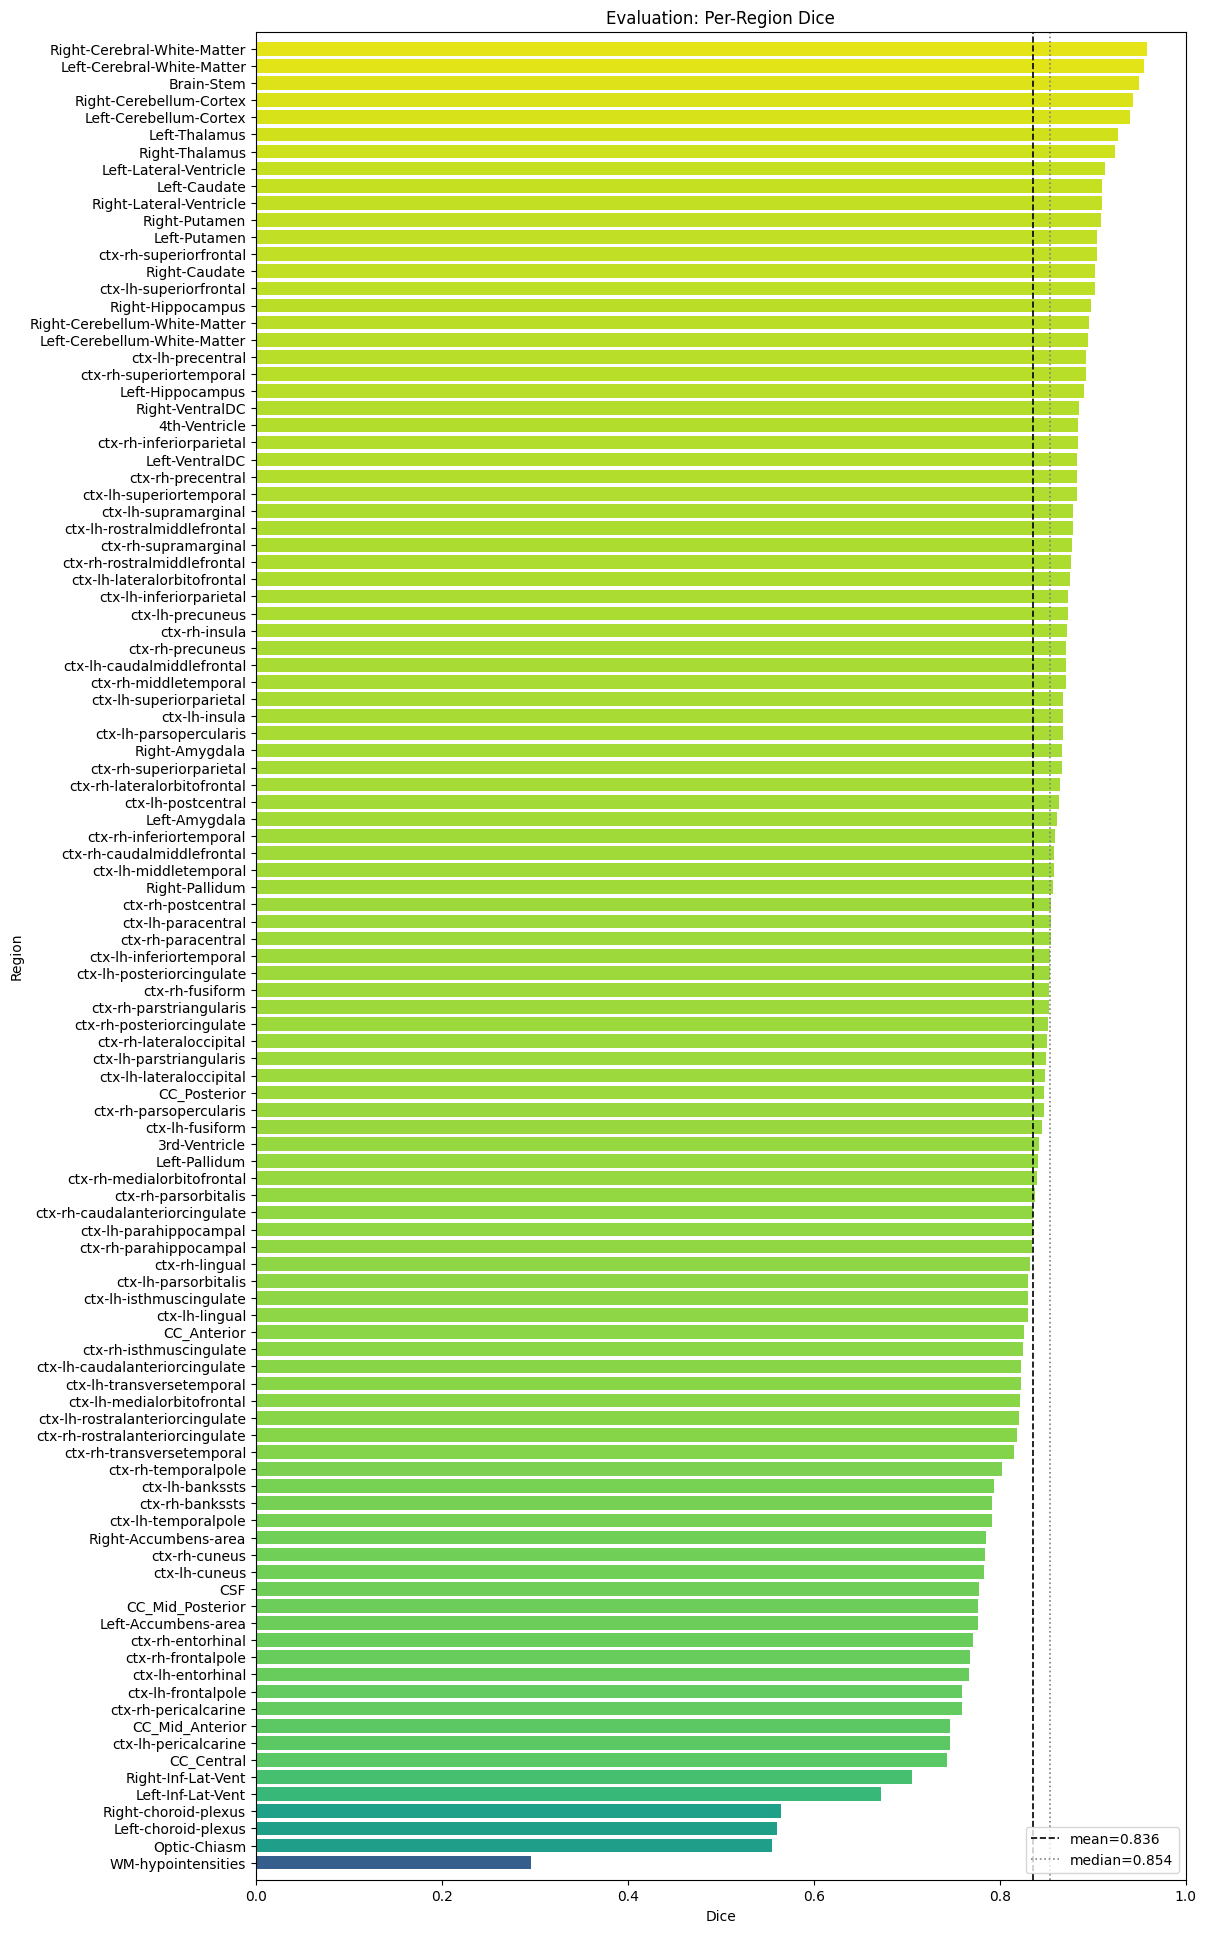

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_region_dice(bundle, ax=None):

    region_plot_df = bundle["region_plot_df"]


    if ax is None:
        fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(12, 24))
    norm = plt.Normalize(vmin=0.0, vmax=1.0)
    colors = plt.cm.viridis(norm(region_plot_df["dice"].values))

    ax.barh(
        region_plot_df["label"],
        region_plot_df["dice"],
        color=colors,
        edgecolor="none"
    )
    ax.set_xlim(0.0, 1.0)
    ax.set_xlabel("Dice")
    ax.set_ylabel("Region")
    ax.set_title(f"{dataset_label}: Per-Region Dice")
    mean_dice = float(region_plot_df["dice"].mean()) if len(region_plot_df) else np.nan
    median_dice = float(region_plot_df["dice"].median()) if len(region_plot_df) else np.nan
    if np.isfinite(mean_dice):
        ax.axvline(mean_dice, color="black", linestyle="--", linewidth=1.2, label=f"mean={mean_dice:.3f}")
    if np.isfinite(median_dice):
        ax.axvline(median_dice, color="gray", linestyle=":", linewidth=1.2, label=f"median={median_dice:.3f}")
    if ax.get_legend_handles_labels()[0]:
        ax.legend(loc="lower right")
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    plt.ylim(-1, 107)

bundle = report["plot_bundle"]
dataset_label="Evaluation"

plot_region_dice(bundle)
plt.savefig("region_dice_plot.png", dpi=300, bbox_inches="tight")

,class_idx,region_name,dice,vol_true,vol_pred,label
0,38,WM-hypointensities,0.296339,463619,146662,WM-hypointensities
1,40,Optic-Chiasm,0.555435,55942,42417,Optic-Chiasm
2,20,Left-choroid-plexus,0.559846,276881,191441,Left-choroid-plexus
3,36,Right-choroid-plexus,0.564853,294440,214188,Right-choroid-plexus
4,4,Left-Inf-Lat-Vent,0.671830,103236,93799,Left-Inf-Lat-Vent
...,...,...,...,...,...,...
102,6,Left-Cerebellum-Cortex,0.939518,24095637,24311474,Left-Cerebellum-Cortex
103,26,Right-Cerebellum-Cortex,0.942746,24346742,24517191,Right-Cerebellum-Cortex
104,13,Brain-Stem,0.949138,8975587,8997869,Brain-Stem
105,1,Left-Cerebral-White-Matter,0.954753,97215816,97621676,Left-Cerebral-White-Matter


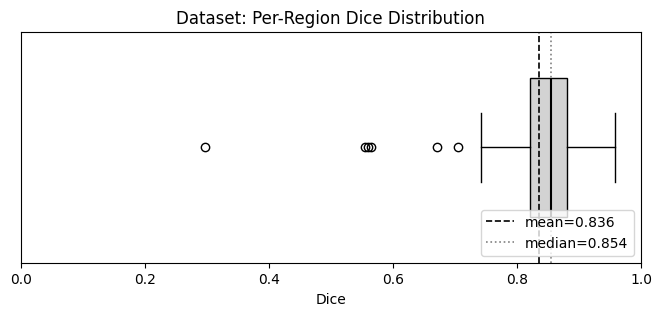

In [ ]:
def plot_region_dice(bundle, ax=None, dataset_label="Dataset"):
    region_plot_df = bundle["region_plot_df"]

    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(8, 3))

    dice = region_plot_df["dice"].dropna().to_numpy()

    ax.boxplot(
        dice,
        vert=False,
        widths=0.6,
        patch_artist=True,
        boxprops=dict(facecolor="lightgray", edgecolor="black"),
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
    )

    ax.set_xlim(0.0, 1.0)
    ax.set_xlabel("Dice")
    ax.set_yticks([])
    ax.set_title(f"{dataset_label}: Per-Region Dice Distribution")

    mean_dice = float(np.mean(dice)) if len(dice) else np.nan
    median_dice = float(np.median(dice)) if len(dice) else np.nan

    if np.isfinite(mean_dice):
        ax.axvline(mean_dice, color="black", linestyle="--", linewidth=1.2, label=f"mean={mean_dice:.3f}")
    if np.isfinite(median_dice):
        ax.axvline(median_dice, color="gray", linestyle=":", linewidth=1.2, label=f"median={median_dice:.3f}")

    if ax.get_legend_handles_labels()[0]:
        ax.legend(loc="lower right")


plot_region_dice(bundle)

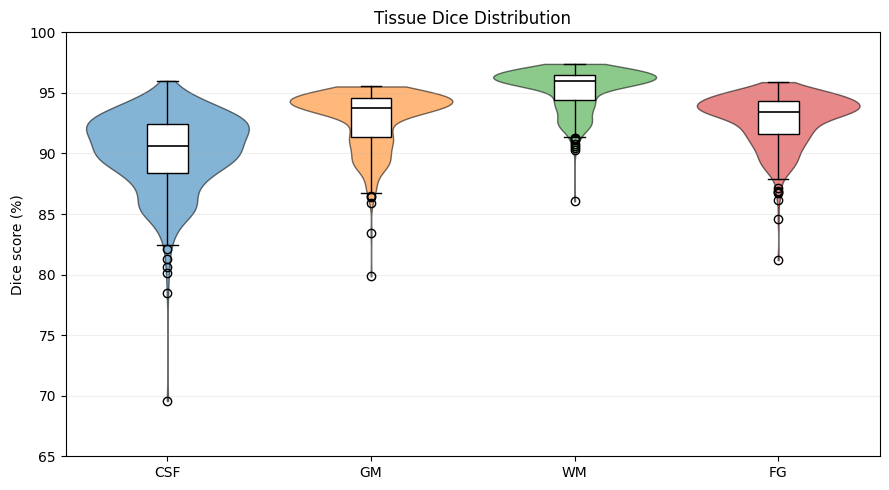

In [23]:
import matplotlib.pyplot as plt
import numpy as np

def plot_tissue_dice(bundle, ax=None):
    """Tissue Dice distribution."""
    tissue_long_df = bundle["tissue_long_df"]
    order = ["CSF", "GM", "WM", "FG"]
    data = [tissue_long_df.loc[tissue_long_df["tissue"] == t, "dice_plot"].values for t in order]
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    positions = np.arange(1, len(order) + 1)
    vp = ax.violinplot(data, positions=positions, widths=0.8, showmeans=False, showmedians=False, showextrema=False)
    for body, color in zip(vp["bodies"], ["C0", "C1", "C2", "C3"]):
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.55)
    ax.boxplot(
        data,
        positions=positions,
        widths=0.20,
        patch_artist=True,
        showfliers=True,
        medianprops={"color": "black", "linewidth": 1.2},
        boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 1.0},
        whiskerprops={"color": "black", "linewidth": 1.0},
        capprops={"color": "black", "linewidth": 1.0},
    )
    ax.set_xticks(positions)
    ax.set_xticklabels(order)
    is_percent = bool(len(tissue_long_df) and str(tissue_long_df["dice_unit"].iloc[0]) == "%")
    ax.set_ylabel("Dice score (%)" if is_percent else "Dice score")
    if is_percent:
        ax.set_ylim(0, 100)
    ax.set_title(f"Tissue Dice Distribution")
    ax.grid(axis="y", alpha=0.2)

    plt.ylim(65, 100)
    plt.tight_layout()
plot_tissue_dice(bundle)
plt.savefig("tissue_dice_plot.png", dpi=300, bbox_inches="tight")


In [ ]:
# Napari viewer for FIRST sample from FIRST plotted dataset (Test Set).
# This path auto-pads to patch size, so no shape-divisibility crash.
import napari

first_test_idx = int(
    test_sample_metrics_df.loc[test_sample_metrics_df["method"] == "model", "sample_idx"].min()
)

napari_payload = prepare_napari_sample_from_test_dataset(
    model=model,
    pipeline=pipeline,
    class_values=class_values,
    sample_idx=first_test_idx,
    patch_size=patch_size_eval,
    patch_chunk_size=patch_chunk_size_eval,
    region_df=region_df,
    device=DEVICE,
)

napari_payload["pred_csf_bin"][napari_payload["pred_csf_bin"] == 1] = 2
napari_payload["pred_gm_bin"][napari_payload["pred_gm_bin"] == 1] = 3
napari_payload["pred_wm_bin"][napari_payload["pred_wm_bin"] == 1] = 4
napari_payload["pred_fg_bin"][napari_payload["pred_fg_bin"] == 1] = 5

napari_payload["gt_csf_bin"][napari_payload["gt_csf_bin"] == 1] = 6
napari_payload["gt_gm_bin"][napari_payload["gt_gm_bin"] == 1] = 7
napari_payload["gt_wm_bin"][napari_payload["gt_wm_bin"] == 1] = 8
napari_payload["gt_fg_bin"][napari_payload["gt_fg_bin"] == 1] = 9


viewer = napari.Viewer()
viewer.add_image(napari_payload["x"], name="rawavg (test set)", colormap="gray")

viewer.add_labels(napari_payload["y_true_fs"], name="aparc+aseg GT (FS IDs)")
viewer.add_labels(napari_payload["y_pred_fs"], name="prediction (FS IDs)")

# viewer.add_labels(napari_payload["gt_csf_bin"], name="GT CSF (binary)", opacity=0.45)
# viewer.add_labels(napari_payload["gt_gm_bin"], name="GT GM (binary)", opacity=0.45)
# viewer.add_labels(napari_payload["gt_wm_bin"], name="GT WM (binary)", opacity=0.45)
# viewer.add_labels(napari_payload["gt_fg_bin"], name="GT FG (binary)", opacity=0.45)

# viewer.add_labels(napari_payload["pred_gm_bin"], name="Pred GM (binary)", opacity=0.45, colormap="Set1")
# viewer.add_labels(napari_payload["pred_wm_bin"], name="Pred WM (binary)", opacity=0.45, colormap="Set1")
# viewer.add_labels(napari_payload["pred_fg_bin"], name="Pred FG (binary)", opacity=0.45, colormap="Set1")

viewer.add_labels(napari_payload["gt_csf_bin"] + napari_payload["gt_wm_bin"] + napari_payload["gt_gm_bin"],
                  name="XGT CSF (binary)", opacity=0.45)


viewer.add_labels(napari_payload["pred_csf_bin"] + napari_payload["pred_wm_bin"] + napari_payload["pred_gm_bin"],
                  name="XPred CSF (binary)", opacity=0.45)


viewer.add_labels(napari_payload["gt_fg_bin"],
                  name="GT FG (binary)", opacity=0.45)


viewer.add_labels(napari_payload["pred_fg_bin"],
                  name="Pred FG (binary)", opacity=0.45)


viewer.add_labels(napari_payload["gt_csf_bin"],
                  name="GT CSF (binary)", opacity=0.45)


viewer.add_labels(napari_payload["pred_csf_bin"],
                  name="Pred CSF (binary)", opacity=0.45)

napari.run()


In [ ]:

napari_payload = prepare_napari_sample_from_test_dataset(
    model=model,
    pipeline=pipeline,
    class_values=class_values,
    sample_idx=first_test_idx,
    patch_size=patch_size_eval,
    patch_chunk_size=patch_chunk_size_eval,
    region_df=region_df,
    device=DEVICE,
)


((napari_payload["gt_csf_bin"]+ napari_payload["pred_csf_bin"]) == 2).sum() / (napari_payload["gt_csf_bin"].sum() + napari_payload["pred_csf_bin"].sum())

In [ ]:
# Dice = 2 * |A ∩ B| / (|A| + |B|)
gt = napari_payload["gt_csf_bin"].astype(bool)
pred = napari_payload["pred_csf_bin"].astype(bool)

intersection = np.logical_and(gt, pred).sum()
denom = gt.sum() + pred.sum()

dice_csf = (2.0 * intersection / denom) if denom > 0 else 1.0
print(dice_csf)

In [ ]:
# # Napari view for SECOND dataset (throughput mgz set)

# import napari
# import numpy as np
# import torch

# from segmentation.convert import prepare_arrays_if_needed
# from segmentation.metrics import (
#     preprocess_mgz_pair_to_padded_tensors,
#     infer_tissue_class_indices,
# )

# # Pick a sample from throughput dataset (second dataset in notebook)
# row = throughput_sample_metrics_df.sort_values(["study", "subject", "rawavg_path"]).iloc[10]
# rawavg_path = row["rawavg_path"]
# aparc_path = row["aparc_path"]

# # GT image + FS labels on aligned/preprocessed grid
# x_arr, aparc_fs = prepare_arrays_if_needed(rawavg_path, aparc_path)

# # Model prediction with same preprocessing path used in throughput eval
# x_pad, _ = preprocess_mgz_pair_to_padded_tensors(
#     rawavg_path=rawavg_path,
#     aparc_path=aparc_path,
#     label_lut=pipeline.label_lut,
#     apply_zscore=apply_zscore_eval,
#     patch_size=patch_size_eval,
# )

# with torch.inference_mode():
#     y_pred_dense = model.predict_volume(
#         x_pad.unsqueeze(0).unsqueeze(0).to(DEVICE).float(),
#         patch_chunk_size=patch_chunk_size_eval,
#     )[0].cpu().long()

# # Crop away pad and map dense y -> FS IDs
# D, H, W = x_arr.shape
# y_pred_dense = y_pred_dense[:D, :H, :W]
# pred_fs = class_values[y_pred_dense].numpy().astype(np.int32)

# # CSF binary masks
# tissue_idx = infer_tissue_class_indices(class_values=class_values, region_df=region_df)
# csf_fs = np.array([int(class_values[i].item()) for i in tissue_idx["CSF"]], dtype=np.int32)
# gt_csf_bin = np.isin(aparc_fs.astype(np.int32), csf_fs).astype(np.uint8)
# pred_csf_bin = np.isin(pred_fs, csf_fs).astype(np.uint8)

# viewer = napari.Viewer()
# viewer.add_image(x_arr.astype(np.float32), name="rawavg (throughput)", colormap="gray")
# viewer.add_labels(aparc_fs.astype(np.int32), name="aparc+aseg GT (FS IDs)")
# viewer.add_labels(pred_fs, name="prediction (FS IDs)")
# viewer.add_labels(gt_csf_bin, name="GT CSF (binary)", opacity=0.45)
# viewer.add_labels(pred_csf_bin, name="Pred CSF (binary)", opacity=0.45)
# napari.run()
